In [19]:
import html
import re
#Xử lý các review
def data_processing(text):
    text = html.unescape(str(text))
    text = text.lower()

    # Xóa các biến thể của <br>
    text = re.sub(r'<br\s*/?>', '', text)

    # Xóa HTML tag còn lại
    text = re.sub(r'<[^>]+>', '', text)

    # Xóa URL
    text = re.sub(
        r'https?://\S+|www\.\S+',
        ' ', text
    )

    # Giữ chữ, số, khoảng trắng và dấu nháy đơn
    text = re.sub( r"[^a-z0-9\s']",' ',text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()

    return text




RNN

In [2]:
import pandas as pd

train_df = pd.read_csv("train.csv")
validation_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (34703, 2)
Validation: (7437, 2)
Test: (7437, 2)


In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

RNN_SEED = 42

random.seed(RNN_SEED)
np.random.seed(RNN_SEED)
tf.keras.utils.set_random_seed(RNN_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
rnn_train_df = (
    train_df[["clean_review", "label"]]
    .dropna()
    .copy()
)

rnn_val_df = (
    validation_df[["clean_review", "label"]]
    .dropna()
    .copy()
)

rnn_test_df = (
    test_df[["clean_review", "label"]]
    .dropna()
    .copy()
)

for data in [
    rnn_train_df,
    rnn_val_df,
    rnn_test_df
]:
    data["clean_review"] = (
        data["clean_review"]
        .astype(str)
    )

    data["label"] = (
        data["label"]
        .astype("int32")
    )

print("Train:", rnn_train_df.shape)
print("Validation:", rnn_val_df.shape)
print("Test:", rnn_test_df.shape)

print("\nPhân bố nhãn train:")
print(rnn_train_df["label"].value_counts())

Train: (34703, 2)
Validation: (7437, 2)
Test: (7437, 2)

Phân bố nhãn train:
label
1    17416
0    17287
Name: count, dtype: int64


In [5]:
x_train_rnn = (
    rnn_train_df["clean_review"]
    .to_numpy(dtype=str)
)

y_train_rnn = (
    rnn_train_df["label"]
    .to_numpy(dtype="float32")
)

x_val_rnn = (
    rnn_val_df["clean_review"]
    .to_numpy(dtype=str)
)

y_val_rnn = (
    rnn_val_df["label"]
    .to_numpy(dtype="float32")
)

x_test_rnn = (
    rnn_test_df["clean_review"]
    .to_numpy(dtype=str)
)

y_test_rnn = (
    rnn_test_df["label"]
    .to_numpy(dtype="float32")
)

print("x_train:", x_train_rnn.shape)
print("y_train:", y_train_rnn.shape)
print("x_validation:", x_val_rnn.shape)
print("x_test:", x_test_rnn.shape)

x_train: (34703,)
y_train: (34703,)
x_validation: (7437,)
x_test: (7437,)


In [6]:
MAX_TOKENS = 40000
SEQUENCE_LENGTH = 400
EMBEDDING_DIM = 128

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=None,
    split="whitespace",
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    name="text_vectorization"
)

vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(x_train_rnn)
    .batch(256)
)

VOCAB_SIZE = vectorizer.vocabulary_size()

print("Vocabulary size:", VOCAB_SIZE)
print("Một số từ:", vectorizer.get_vocabulary()[:20])

Vocabulary size: 40000
Một số từ: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('movie'), np.str_('for'), np.str_('with'), np.str_('but'), np.str_('film')]


In [7]:
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

train_rnn_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (x_train_rnn, y_train_rnn)
    )
    .shuffle(
        buffer_size=len(x_train_rnn),
        seed=RNN_SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_rnn_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (x_val_rnn, y_val_rnn)
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_rnn_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (x_test_rnn, y_test_rnn)
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Đã tạo xong pipeline dữ liệu")

Đã tạo xong pipeline dữ liệu


In [8]:
review_input = tf.keras.Input(
    shape=(),
    dtype=tf.string,
    name="review_text"
)

x = vectorizer(review_input)

x = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="embedding"
)(x)

x = layers.Bidirectional(
    layers.LSTM(
        units=96,
        return_sequences=True,
        dropout=0.20,
        recurrent_dropout=0.0
    ),
    name="bidirectional_lstm_1"
)(x)

x = layers.Bidirectional(
    layers.LSTM(
        units=48,
        return_sequences=False,
        dropout=0.20,
        recurrent_dropout=0.0
    ),
    name="bidirectional_lstm_2"
)(x)

x = layers.Dense(
    units=64,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4),
    name="dense_features"
)(x)

x = layers.BatchNormalization(
    name="batch_normalization"
)(x)

x = layers.Dropout(
    rate=0.40,
    name="classifier_dropout"
)(x)

sentiment_output = layers.Dense(
    units=1,
    activation="sigmoid",
    dtype="float32",
    name="sentiment_probability"
)(x)

rnn_model = tf.keras.Model(
    inputs=review_input,
    outputs=sentiment_output,
    name="movie_review_bilstm"
)

rnn_model.summary()

print(
    "\nTổng số tham số:",
    f"{rnn_model.count_params():,}"
)

Model: "movie_review_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ review_text         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 400)       │          0 │ review_text[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 128)  │  5,120,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 400)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm… │ (None, 400, 192)  │    172,800 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm… │ (None, 96)        │     92,544 │ bidirectional_ls… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 64)        │      6,208 │ bidirectional_ls… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense_features[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dropout  │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_probabil… │ (None, 1)         │         65 │ classifier_dropo… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,391,873 (20.57 MB)

 Trainable params: 5,391,745 (20.57 MB)

 Non-trainable params: 128 (512.00 B)


Tổng số tham số: 5,391,873


In [9]:
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0008,
        clipnorm=1.0
    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("Compile model thành công")

Compile model thành công


In [10]:
from pathlib import Path

RNN_OUTPUT_DIR = Path("outputs/rnn")
RNN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = RNN_OUTPUT_DIR / "best_movie_review_bilstm.keras"

os.makedirs(
    RNN_OUTPUT_DIR,
    exist_ok=True
)

BEST_MODEL_PATH = os.path.join(
    RNN_OUTPUT_DIR,
    "best_movie_review_bilstm_bac.keras"
)

rnn_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=3,
        min_delta=0.0001,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=1,
        min_lr=0.000001,
        verbose=1
    )
]

print("Đã thiết lập callback")

Đã thiết lập callback


In [11]:
history_rnn = rnn_model.fit(
    train_rnn_ds,
    validation_data=val_rnn_ds,
    epochs=15,
    callbacks=rnn_callbacks,
    verbose=1
)

Epoch 1/15
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7471 - auc: 0.8280 - loss: 0.4844 - precision: 0.7443 - recall: 0.7504
Epoch 1: val_loss improved from None to 0.37181, saving model to outputs/rnn/best_movie_review_bilstm_bac.keras

Epoch 1: finished saving model to outputs/rnn/best_movie_review_bilstm_bac.keras
272/272 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.8283 - auc: 0.9146 - loss: 0.3781 - precision: 0.8267 - recall: 0.8322 - val_accuracy: 0.8904 - val_auc: 0.9586 - val_loss: 0.3718 - val_precision: 0.8778 - val_recall: 0.9081 - learning_rate: 8.0000e-04
Epoch 2/15
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9342 - auc: 0.9804 - loss: 0.1823 - precision: 0.9362 - recall: 0.9333
Epoch 2: val_loss did not improve from 0.37181

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00039999998989515007.
272/272 ━━━━━━━━━━━━━━━━━━━━ 31s 114ms/step - accuracy: 0.9331 - auc: 0.9793 - loss: 0.1873 - precision: 0.9336 - recall: 0.9331 - val_accura

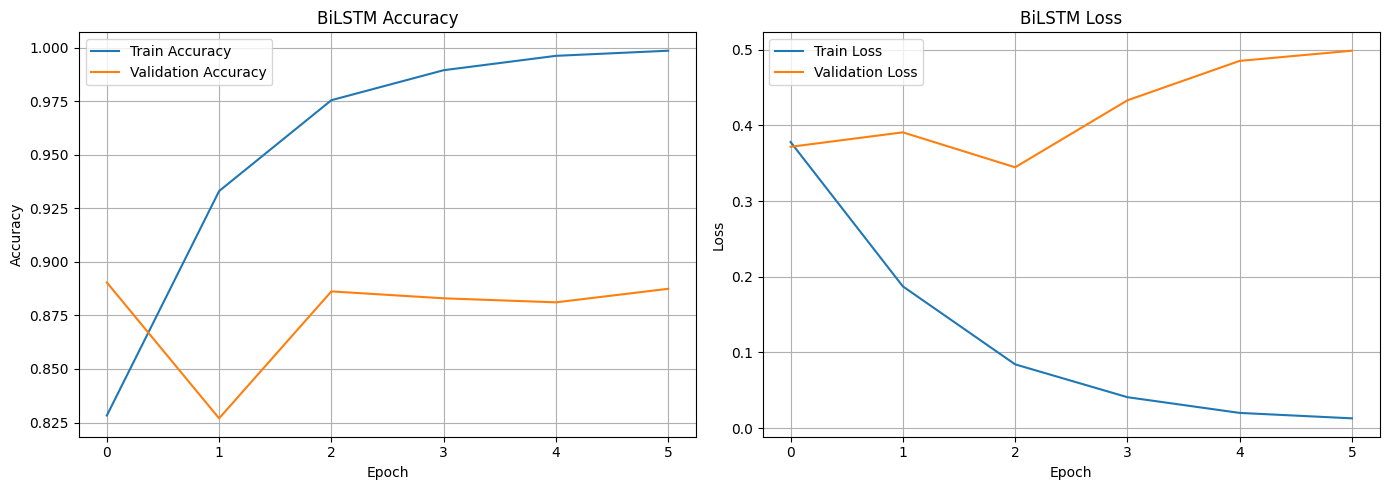

In [12]:
history_rnn_df = pd.DataFrame(
    history_rnn.history
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history_rnn_df["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_rnn_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(
    history_rnn_df["loss"],
    label="Train Loss"
)

plt.plot(
    history_rnn_df["val_loss"],
    label="Validation Loss"
)

plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
val_probabilities = (
    rnn_model.predict(
        val_rnn_ds,
        verbose=1
    )
    .ravel()
)

candidate_thresholds = np.arange(
    0.30,
    0.701,
    0.005
)

validation_accuracies = []

for threshold in candidate_thresholds:
    val_predictions = (
        val_probabilities >= threshold
    ).astype("int32")

    threshold_accuracy = accuracy_score(
        y_val_rnn,
        val_predictions
    )

    validation_accuracies.append(
        threshold_accuracy
    )

best_index = int(
    np.argmax(validation_accuracies)
)

BEST_THRESHOLD = float(
    candidate_thresholds[best_index]
)

BEST_VAL_ACCURACY = float(
    validation_accuracies[best_index]
)

print(
    f"Ngưỡng tốt nhất: {BEST_THRESHOLD:.3f}"
)

print(
    f"Validation Accuracy: "
    f"{BEST_VAL_ACCURACY:.4f}"
)

59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
Ngưỡng tốt nhất: 0.585
Validation Accuracy: 0.8896


In [14]:
test_probabilities = (
    rnn_model.predict(
        test_rnn_ds,
        verbose=1
    )
    .ravel()
)

y_test_pred_rnn = (
    test_probabilities >= BEST_THRESHOLD
).astype("int32")

rnn_accuracy = accuracy_score(
    y_test_rnn,
    y_test_pred_rnn
)

rnn_precision = precision_score(
    y_test_rnn,
    y_test_pred_rnn,
    zero_division=0
)

rnn_recall = recall_score(
    y_test_rnn,
    y_test_pred_rnn,
    zero_division=0
)

rnn_f1 = f1_score(
    y_test_rnn,
    y_test_pred_rnn,
    zero_division=0
)

rnn_auc = roc_auc_score(
    y_test_rnn,
    test_probabilities
)

print("KẾT QUẢ MÔ HÌNH RNN")
print("-" * 40)
print(f"Accuracy : {rnn_accuracy:.4f}")
print(f"Precision: {rnn_precision:.4f}")
print(f"Recall   : {rnn_recall:.4f}")
print(f"F1-score : {rnn_f1:.4f}")
print(f"ROC-AUC  : {rnn_auc:.4f}")
print(f"Threshold: {BEST_THRESHOLD:.3f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
KẾT QUẢ MÔ HÌNH RNN
----------------------------------------
Accuracy : 0.8907
Precision: 0.8844
Recall   : 0.8998
F1-score : 0.8920
ROC-AUC  : 0.9579
Threshold: 0.585


In [15]:
print(
    classification_report(
        y_test_rnn,
        y_test_pred_rnn,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative     0.8973    0.8815    0.8893      3705
    Positive     0.8844    0.8998    0.8920      3732

    accuracy                         0.8907      7437
   macro avg     0.8908    0.8906    0.8907      7437
weighted avg     0.8908    0.8907    0.8907      7437



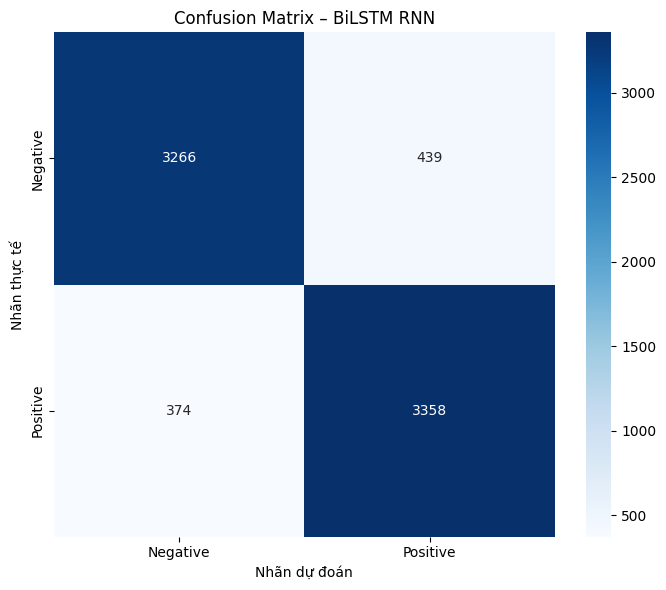

True Negative : 3266
False Positive: 439
False Negative: 374
True Positive : 3358


In [16]:
rnn_cm = confusion_matrix(
    y_test_rnn,
    y_test_pred_rnn
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title("Confusion Matrix – BiLSTM RNN")
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = rnn_cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

In [17]:
FINAL_MODEL_PATH = (
    RNN_OUTPUT_DIR / "movie_review_bilstm.keras"
)

METRICS_PATH = (
    RNN_OUTPUT_DIR / "rnn_metrics.json"
)

HISTORY_PATH = (
    RNN_OUTPUT_DIR / "rnn_training_history.csv"
)

PREDICTIONS_PATH = (
    RNN_OUTPUT_DIR / "rnn_test_predictions.csv"
)

rnn_model.save(FINAL_MODEL_PATH)

history_rnn_df.to_csv(
    HISTORY_PATH,
    index=False
)

rnn_metrics = {
    "model": "Bidirectional LSTM",
    "accuracy": float(rnn_accuracy),
    "precision": float(rnn_precision),
    "recall": float(rnn_recall),
    "f1_score": float(rnn_f1),
    "roc_auc": float(rnn_auc),
    "best_threshold": float(BEST_THRESHOLD),
    "validation_accuracy": float(
        BEST_VAL_ACCURACY
    ),
    "vocabulary_size": int(VOCAB_SIZE),
    "sequence_length": int(
        SEQUENCE_LENGTH
    ),
    "number_of_parameters": int(
        rnn_model.count_params()
    )
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        rnn_metrics,
        file,
        ensure_ascii=False,
        indent=2
    )

pd.DataFrame({
    "actual_label": (
        y_test_rnn.astype("int32")
    ),
    "predicted_label": y_test_pred_rnn,
    "positive_probability": (
        test_probabilities
    )
}).to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("ĐÃ LƯU THÀNH CÔNG")
print(FINAL_MODEL_PATH)
print(METRICS_PATH)
print(HISTORY_PATH)
print(PREDICTIONS_PATH)

ĐÃ LƯU THÀNH CÔNG
outputs/rnn/movie_review_bilstm.keras
outputs/rnn/rnn_metrics.json
outputs/rnn/rnn_training_history.csv
outputs/rnn/rnn_test_predictions.csv


In [20]:
def predict_rnn_sentiment(review_text):
    cleaned_review = data_processing(review_text)

    positive_probability = float(
        rnn_model.predict(
            tf.constant([cleaned_review]),
            verbose=0
        )[0][0]
    )

    negative_probability = 1.0 - positive_probability

    sentiment = (
        "Positive"
        if positive_probability >= BEST_THRESHOLD
        else "Negative"
    )

    print("Review:", review_text)
    print("Sentiment:", sentiment)
    print(
        f"Positive probability: "
        f"{positive_probability:.4f}"
    )
    print(
        f"Negative probability: "
        f"{negative_probability:.4f}"
    )
    print(
        f"Decision threshold: "
        f"{BEST_THRESHOLD:.3f}"
    )


predict_rnn_sentiment(
    "I loved this movie. "
    "The story and acting were excellent."
)

predict_rnn_sentiment(
    "This movie was boring and "
    "a complete waste of time."
)

Review: I loved this movie. The story and acting were excellent.
Sentiment: Positive
Positive probability: 0.9174
Negative probability: 0.0826
Decision threshold: 0.585
Review: This movie was boring and a complete waste of time.
Sentiment: Negative
Positive probability: 0.0017
Negative probability: 0.9983
Decision threshold: 0.585
